# GPU Barnes–Hut DBH galaxy (usage guide)

End-to-end recipe: **GalactICS Python ICs** (disk + bulge + halo) → **OpenMP
sampling** → **ntropy** adaptive `tiered_leapfrog` + **`gpu_bh`**.

This notebook is the primary **usage walkthrough**. Algorithm detail lives in
docs; keep this file runnable.

| Doc | Topic |
| --- | --- |
| [`GPU_BLACKWELL.md`](../src/ntropy/ntropy/forces/GPU_BLACKWELL.md) | CuPy-before-BH, GPU walk, Blackwell notes |
| [`ic_sampling.md`](../docs/ic_sampling.md) | OpenMP gen*, bulge DF / Cartesian velocities, potential virial |
| [`galacticsics_pipeline.md`](../docs/galacticsics_pipeline.md) | Full DBH → sample → evolve pipeline |
| [`ci_essential.md`](../docs/ci_essential.md) | Essential PR pytest gate (`make test-essential`) |

**Default particle counts at `SCALE=1`:** 5×10⁶ disk · 1×10⁶ bulge · 1×10⁶ halo  
Use `SCALE=0.01` for a quick dry-run.

| Quantity | Unit |
| --- | --- |
| Length | kpc |
| Velocity | 100 km/s |
| Mass | 2.325×10⁹ M☉ |
| Time | 1 code ≈ 9.78 Myr |
| G | 1 |

### Prerequisites (read before running)

1. **Import CuPy and touch the device before any ntropy / `bhtree_c` import** (Blackwell / cuBLAS). The next cell does this.
2. Rebuild OpenMP extensions after pulling C changes:  
   `.venv/bin/python setup.py build_ext --inplace` then **restart the kernel**.
3. `SampleConfig.use_openmp=True` (default) parallelizes disk, halo, **and** bulge rejection sampling.
4. IC equilibrium is checked against **∇Ψ** from `dbh.dat`, not softened N-body pairwise virial (see § IC validation).


In [1]:
from __future__ import annotations

# CuPy FIRST — required on Blackwell before bhtree_c / cuBLAS
import cupy as cp

cp.cuda.runtime.setDevice(0)
_ = cp.zeros(1, dtype=cp.float64)
cp.cuda.runtime.deviceSynchronize()

import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from galacticsics.models import GalaxyModel, PotentialGrid, SersicBulge
from galacticsics.sampling.sampler import SampleConfig
from ntropy.analysis.density import bin_spherical_density
from ntropy.analysis.disk_density import bin_midplane_surface_density
from ntropy.config import (
    BhOptimizationsConfig,
    ForceConfig,
    IntegratorConfig,
    OutputConfig,
    RunConfig,
)
from ntropy.forces.gpu_bh import gpu_bh_available
from ntropy.integrators.timestep import TimestepConfig
from ntropy.integrations.galacticsics import require_galacticsics, sample_galacticsics_galaxy
from ntropy.particle_types import TypeRegistry
from ntropy.simulation import Simulation
from ntropy.units import code_time_to_myr

require_galacticsics()
assert gpu_bh_available(), "GPU BH requires CuPy + a CUDA device"

REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
ART = REPO / "notebooks" / "artifacts" / "gpu_bh_dbh"
ART.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(ART / ".matplotlib"))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

props = cp.cuda.runtime.getDeviceProperties(0)
name = props["name"]
print("GPU:", name.decode() if isinstance(name, bytes) else name)
print("Artifacts:", ART)

GPU: NVIDIA RTX PRO 5000 Blackwell
Artifacts: /home/jbauer/PyGalactICS/notebooks/artifacts/gpu_bh_dbh


## 1 · Parameters

Set `SCALE < 1` for a quick dry-run (e.g. `0.01` → 50k / 10k / 10k).

Softening should stay well below component scale lengths (bulge $a \approx 0.6$ kpc
→ `eps_bulge=0.03`). Large $\varepsilon/a$ cores the cusp even when the DF is correct.


In [2]:
SCALE = 1.0  # e.g. 0.01 → 50k / 10k / 10k

N_DISK = int(5_000_000 * SCALE)
N_BULGE = int(1_000_000 * SCALE)
N_HALO = int(1_000_000 * SCALE)

THETA = 0.8
T_END_GYR = 0.5  # 50 Myr
DT_BASE = 0.05    # code units ≈ 0.5 Myr
DUMP_EVERY = 50   # fine substeps between particle dumps

# Softening ≪ component scale lengths (bulge a ≈ 0.6 kpc)
EPS = {"disk": 0.05, "bulge": 0.03, "halo": 0.2}
COLORS = {"disk": "C0", "bulge": "C1", "halo": "C2"}

print(f"N = {N_DISK + N_BULGE + N_HALO:,}  (disk={N_DISK:,}, bulge={N_BULGE:,}, halo={N_HALO:,})")
print(f"Evolve {T_END_GYR * 1000:.0f} Myr  ·  adaptive tiered leapfrog  ·  dump every {DUMP_EVERY} steps")

N = 7,000,000  (disk=5,000,000, bulge=1,000,000, halo=1,000,000)
Evolve 500 Myr  ·  adaptive tiered leapfrog  ·  dump every 50 steps


## 2 · Build & sample DBH ICs

- **Poisson + DF tables** via `solve=True` (OpenMP polar by default when `_poisson_c` is built).
- **Sampling** uses OpenMP `_sampler_c` for disk, halo, and bulge (`use_openmp=True`).
- Bulge **positions**: spherical `(r, μ, φ)` with weight $\propto r^2\rho(r)$ (not legacy cylindrical `R, z=R·tan v`).
- Bulge **velocities**: Cartesian draw in the escape sphere; `stream_bulge=0.5` only balances cylindrical $v_\phi$ signs (isotropic Eddington — not net rotation).
- DF table: densψ-based Eddington (no high-$E$ floor). See [`ic_sampling.md`](../docs/ic_sampling.md).


In [3]:
base = GalaxyModel.reference_disk_halo()
model = replace(
    base,
    bulge=SersicBulge(n_sersic=4.0, ppp=0.5, v0=1.8, a=0.6, enabled=True),
    grid=PotentialGrid(dr=0.05, nr=4000, lmax=4),
)

ic_dir = ART / "ic"
sample = sample_galacticsics_galaxy(
    model,
    SampleConfig(
        n_disk=N_DISK,
        n_bulge=N_BULGE,
        n_halo=N_HALO,
        stream_bulge=0.5,  # isotropic Eddington (not 100% retrograde)
        run_diskdf=True,
        center=True,
        use_openmp=True,
    ),
    work_dir=ic_dir,
    eps_by_component=EPS,
    solve=True,
    timeout=3600.0,
)
state0 = sample.state.copy()
print("Components:", sample.components)
print("Total N:", state0.n)

# Sanity: bulge streaming should be ~isotropic
bul = state0.tags == "bulge"
x, y = state0.pos[bul, 0], state0.pos[bul, 1]
vx, vy = state0.vel[bul, 0], state0.vel[bul, 1]
R = np.hypot(x, y)
vphi = np.where(R > 0, (-y * vx + x * vy) / R, 0.0)
frac_pos = float((vphi > 0).mean())
print(f"Bulge frac(vφ>0) = {frac_pos:.3f}  (expect ~0.5)")
assert 0.35 < frac_pos < 0.65, "bulge streaming still anisotropic — check stream_bulge / DF"

np.savez_compressed(
    ART / "ic_state.npz",
    pos=state0.pos, vel=state0.vel, mass=state0.mass, eps=state0.eps,
    tags=state0.tags.astype("U16"),
)

Components: {'disk': 5000000, 'halo': 1000000, 'bulge': 1000000}
Total N: 7000000
Bulge frac(vφ>0) = 0.500  (expect ~0.5)


## 2b · IC validation (potential virial)

GalactICS ICs are equilibrium in the **fixed** `dbh` potential $\Psi$. Check
$2K/|W|\approx 1$ with $W=\sum m\,\mathbf{x}\cdot\nabla\Psi$ — **not** softened
pairwise $N$-body virial (that under-binds a dense bulge when $\varepsilon$ is finite).

Also sanity-check bulge morphology ($z_\mathrm{rms}/R_\mathrm{rms}\sim 1/\sqrt{2}$) and
streaming fraction.


In [4]:
from galacticsics.diagnostics import virial_diagnostic_potential
from galacticsics.sampling.openmp import openmp_sampler_status

print("Sampler backend:", openmp_sampler_status(SampleConfig(use_openmp=True)).log_label())

# Subsample for ∇Ψ finite differences (full N is slow in pure Python)
rng = np.random.default_rng(0)
n_vir = min(12_000, state0.n)
idx = rng.choice(state0.n, size=n_vir, replace=False)
vir = virial_diagnostic_potential(
    state0.pos[idx],
    state0.vel[idx],
    state0.mass[idx],
    ic_dir / "dbh.dat",
    rtol=0.25,
)
print(
    f"Potential virial (N={n_vir:,}): 2K/|W|={vir['virial_ratio']:.3f}  "
    f"resid={vir['virial_residual_rel']:.3f}  ok={vir['is_virial_equilibrium']}"
)
assert vir["is_virial_equilibrium"], vir

# Bulge shape: sphere ⇒ z_rms / R_rms ≈ 1/√2 ≈ 0.707
bul = state0.tags == "bulge"
R = np.hypot(state0.pos[bul, 0], state0.pos[bul, 1])
zrms = float(np.sqrt(np.average(state0.pos[bul, 2] ** 2, weights=state0.mass[bul])))
Rrms = float(np.sqrt(np.average(R * R, weights=state0.mass[bul])))
print(f"Bulge z_rms/R_rms = {zrms / Rrms:.3f}  (expect ~0.55–0.90 for a sphere)")
assert 0.55 < zrms / Rrms < 0.90, "bulge morphology not spherical"


Sampler backend: OpenMP/all cores
Potential virial (N=12,000): 2K/|W|=1.032  resid=0.032  ok=True
Bulge z_rms/R_rms = 0.706  (expect ~0.55–0.90 for a sphere)


## 3 · Evolve (single adaptive run + checkpoints)

One `Simulation` with `tiered_leapfrog` + `gpu_bh`.

**Important:** `BhOptimizationsConfig.from_preset("optimized")` enables
`native_pack`. The GPU path forces legacy 19-float node rows for unpacking —
see [`GPU_BLACKWELL.md`](../src/ntropy/ntropy/forces/GPU_BLACKWELL.md). Particle
dumps land in `run/particles/step_*.npz`.


In [5]:
registry = TypeRegistry.default_galaxy()
for label, eps in EPS.items():
    if label in registry.types:
        registry.types[label].eps = eps

run_dir = ART / "run"
cfg = RunConfig(
    force=ForceConfig(
        method="gpu_bh",
        theta=THETA,
        rebuild_every=1,
        active_subset=True,
        bh_optimizations=BhOptimizationsConfig.from_preset("optimized"),
    ),
    integrator=IntegratorConfig(
        type="tiered_leapfrog",
        order=2,
        dt_base=DT_BASE,
        end_time_gyr=T_END_GYR,
        timestep=TimestepConfig(
            eta=0.025,
            dt_base=DT_BASE,
            max_bin=5,
            update_every=2,
        ),
    ),
    output=OutputConfig(
        dir=str(run_dir),
        every=0,
        write_final=True,
        diagnostics_every=DUMP_EVERY,
        particle_dump_every=DUMP_EVERY,
        write_particle_bins=True,
    ),
    particle_types=registry,
)

result = Simulation(cfg, state=state0.copy()).run(
    show_progress=True,
    progress_desc="gpu_bh DBH",
    print_config=True,
)
state = result.final_state

np.savez_compressed(
    ART / "final_state.npz",
    pos=state.pos, vel=state.vel, mass=state.mass, eps=state.eps,
    tags=state.tags.astype("U16"),
)
dumps = sorted((run_dir / "particles").glob("step_*.npz"))
print(f"Final N={state.n:,}  ·  {len(dumps)} particle dumps  ·  {run_dir}")

=== gpu_bh DBH ===
  integrator : tiered_leapfrog, order=2
  dt_base    : 0.05000 code units
  end_time   : 0.5 Gyr
  n_substeps : 1022 (fine, global clock)
  duration   : 0.5 Gyr = 51.12 code units in 1022 fine substeps (dt_base=0.05000)
  force      : gpu_bh (theta=0.8)
  parallel   : off
  seed       : 42
[ntropy] gpu_bh DBH: N=7,000,000, 1022 fine substeps → 0.5 Gyr (dt_base=0.05000)
[ntropy] initial force evaluation…
step    0/1022 | t=0.0000 Gyr | active 100.0% (7000000) | dE/E0=0.00e+00 | bins 6824427,175573,0,0,0,0 | bulge μb=0.0 disk μb=0.0 halo μb=0.2
[ntropy] integrating…
step   50/1022 | t=0.0244 Gyr | active 100.0% (7000000) | dE/E0=1.69e-02 | bins 6819067,180933,0,0,0,0 | bulge μb=0.0 disk μb=0.0 halo μb=0.2
step  100/1022 | t=0.0489 Gyr | active 100.0% (7000000) | dE/E0=2.80e-02 | bins 6813845,186155,0,0,0,0 | bulge μb=0.0 disk μb=0.0 halo μb=0.2
step  150/1022 | t=0.0733 Gyr | active 100.0% (7000000) | dE/E0=5.04e-02 | bins 6809930,190070,0,0,0,0 | bulge μb=0.0 disk μb=

Final N=7,000,000  ·  25 particle dumps  ·  /home/jbauer/PyGalactICS/notebooks/artifacts/gpu_bh_dbh/run


## 4 · Load checkpoints & diagnostics

In [6]:
!pip install pandas

In [11]:
def component_mask(tags, name):
    return tags == name


def profiles_from_arrays(pos, mass, tags):
    out = {}
    for name in ("disk", "bulge", "halo"):
        m = component_mask(tags, name)
        if not np.any(m):
            continue
        r_max = {"disk": 25.0, "bulge": 8.0, "halo": 80.0}[name]
        out[name] = bin_spherical_density(pos[m], mass[m], n_bins=32, r_max=r_max, r_min=0.1)
    m = component_mask(tags, "disk")
    out["disk_Sigma"] = bin_midplane_surface_density(pos[m], mass[m], n_bins=32, r_max=22.0)
    return out


def size_stats(pos, mass, tags):
    stats = {}
    for name in ("disk", "bulge", "halo"):
        m = component_mask(tags, name)
        if not np.any(m):
            continue
        p, mi = pos[m], mass[m]
        r = np.linalg.norm(p, axis=1)
        order = np.argsort(r)
        cmass = np.cumsum(mi[order])
        rhalf = float(r[order][np.searchsorted(cmass, 0.5 * cmass[-1])])
        zrms = float(np.sqrt(np.average(p[:, 2] ** 2, weights=mi)))
        stats[name] = {"rhalf": rhalf, "zrms": zrms}
    return stats


# Build history from IC + dumps + final
history = {"t_myr": [], "ke": [], "stats": [], "profiles": []}

def _ke(vel, mass):
    return 0.5 * float(np.sum(mass * np.sum(vel * vel, axis=1)))


def push(t_myr, pos, vel, mass, tags):
    history["t_myr"].append(t_myr)
    history["ke"].append(_ke(vel, mass))
    history["stats"].append(size_stats(pos, mass, tags))
    history["profiles"].append(profiles_from_arrays(pos, mass, tags))


push(0.0, state0.pos, state0.vel, state0.mass, state0.tags)

# Map dump step index → time from diagnostics if available
diag_csv = run_dir / "diagnostics.csv"
step_to_t = {}
if diag_csv.is_file():
    import pandas as pd
    ddf = pd.read_csv(diag_csv)
    if "step" in ddf.columns and "t_gyr" in ddf.columns:
        step_to_t = dict(zip(ddf["step"].astype(int), ddf["t_gyr"] * 1000.0))

for path in dumps:
    step = int(path.stem.split("_")[1])
    data = np.load(path)
    tags = data["tags"] if "tags" in data.files else state0.tags
    t_myr = step_to_t.get(step, code_time_to_myr(step * DT_BASE))
    push(float(t_myr), data["pos"], data["vel"], data["mass"], tags)

push(
    T_END_GYR * 1000.0,
    state.pos, state.vel, state.mass, state.tags,
)

t = np.asarray(history["t_myr"])
ke = np.asarray(history["ke"])
print(f"{len(t)} snapshots from t=0 → {t[-1]:.1f} Myr")

27 snapshots from t=0 → 500.0 Myr


## 5 · Diagnostics

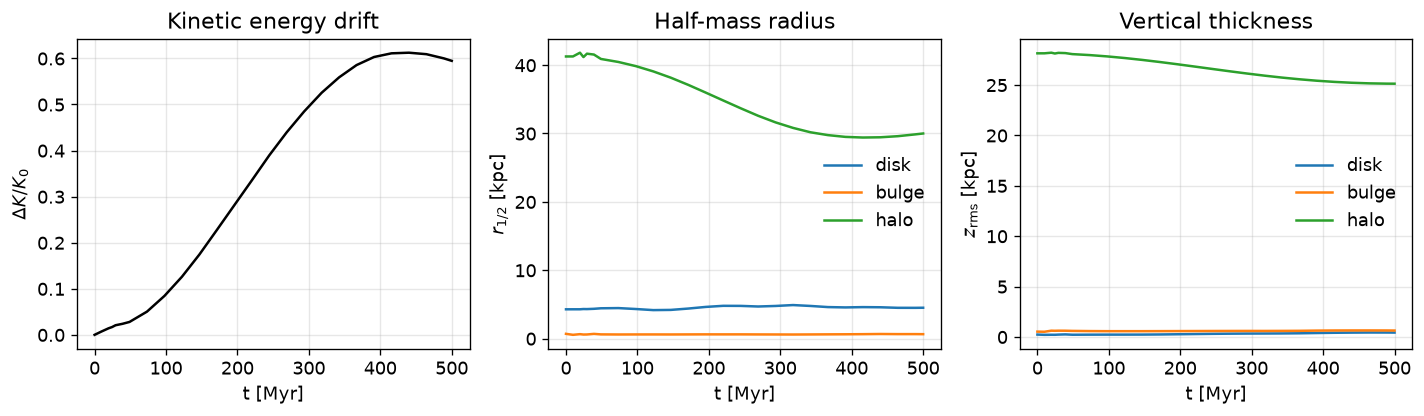

Final |ΔK/K₀| = 5.947e-01


In [12]:
ke0 = ke[0]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

axes[0].plot(t, (ke - ke0) / abs(ke0), "k-")
axes[0].set_xlabel("t [Myr]"); axes[0].set_ylabel(r"$\Delta K / K_0$")
axes[0].set_title("Kinetic energy drift")

for name in ("disk", "bulge", "halo"):
    axes[1].plot(t, [s[name]["rhalf"] for s in history["stats"]], color=COLORS[name], label=name)
axes[1].set_xlabel("t [Myr]"); axes[1].set_ylabel(r"$r_{1/2}$ [kpc]")
axes[1].set_title("Half-mass radius"); axes[1].legend(frameon=False)

for name in ("disk", "bulge", "halo"):
    axes[2].plot(t, [s[name]["zrms"] for s in history["stats"]], color=COLORS[name], label=name)
axes[2].set_xlabel("t [Myr]"); axes[2].set_ylabel(r"$z_{\mathrm{rms}}$ [kpc]")
axes[2].set_title("Vertical thickness"); axes[2].legend(frameon=False)

fig.tight_layout()
fig.savefig(ART / "diagnostics.png")
plt.show()
print(f"Final |ΔK/K₀| = {abs(ke[-1] - ke0) / abs(ke0):.3e}")

## 6 · Density profiles

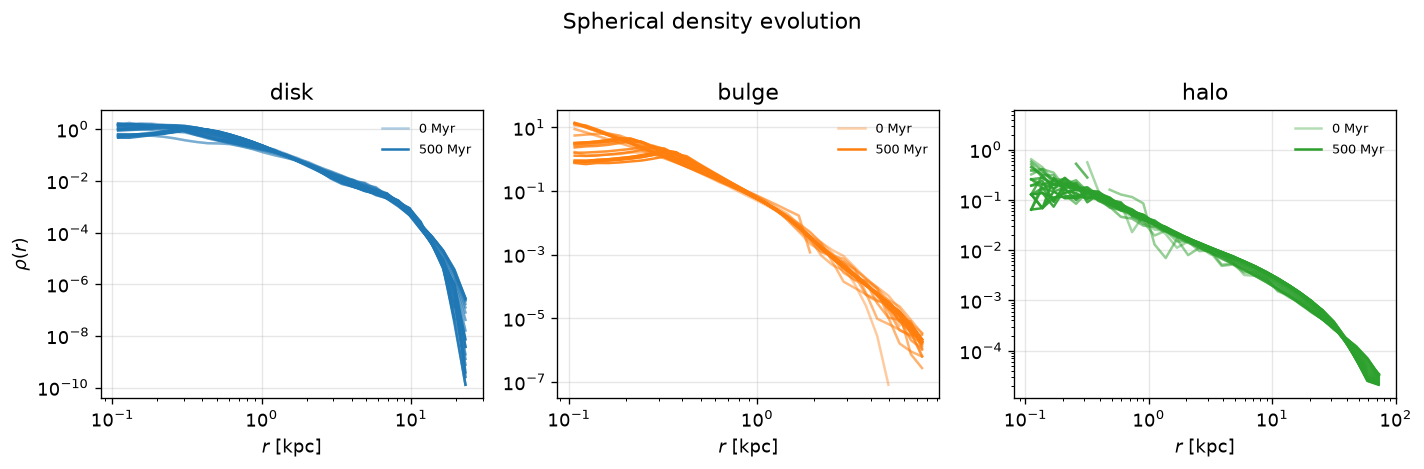

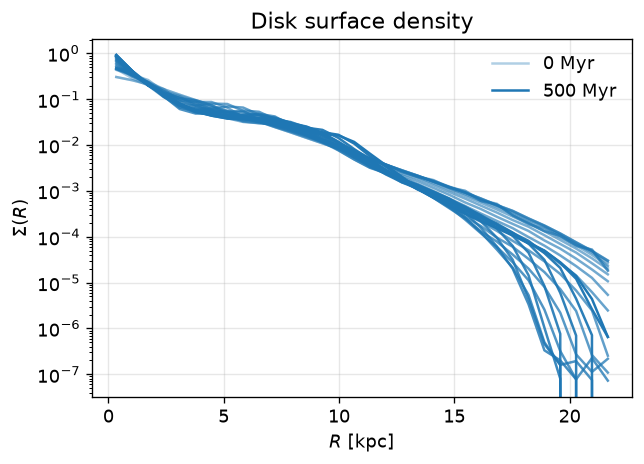

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, name in zip(axes, ("disk", "bulge", "halo")):
    for i, (ti, profs) in enumerate(zip(t, history["profiles"])):
        p = profs[name]
        alpha = 0.35 + 0.65 * (i / max(len(t) - 1, 1))
        ax.loglog(p.r_mid, p.rho, color=COLORS[name], alpha=alpha,
                  label=f"{ti:.0f} Myr" if i in (0, len(t) - 1) else None)
    ax.set_xlabel(r"$r$ [kpc]"); ax.set_title(name); ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel(r"$\rho(r)$")
fig.suptitle("Spherical density evolution", y=1.02)
fig.tight_layout()
fig.savefig(ART / "density_rho.png")
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 4))
for i, (ti, profs) in enumerate(zip(t, history["profiles"])):
    s = profs["disk_Sigma"]
    alpha = 0.35 + 0.65 * (i / max(len(t) - 1, 1))
    ax.semilogy(s.r_mid, s.sigma, color="C0", alpha=alpha,
                label=f"{ti:.0f} Myr" if i in (0, len(t) - 1) else None)
ax.set_xlabel(r"$R$ [kpc]"); ax.set_ylabel(r"$\Sigma(R)$"); ax.set_title("Disk surface density")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ART / "density_sigma.png")
plt.show()

## 7 · Morphology (IC vs final)

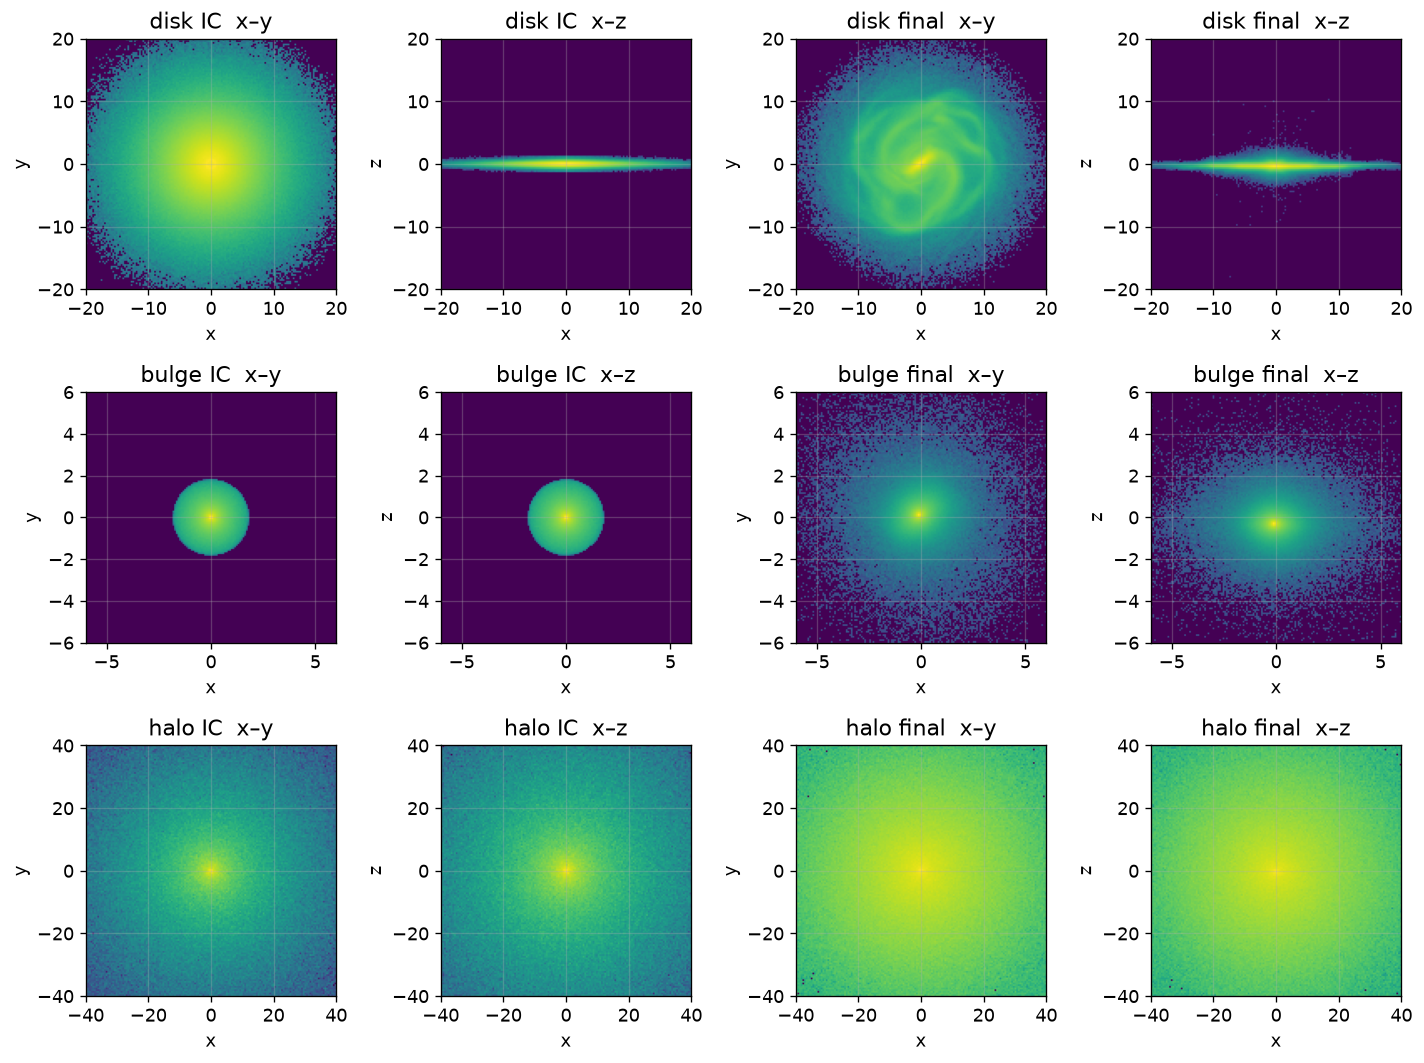

In [14]:
def plane_hist(pos, mass, axes=(0, 1), extent=20.0, nb=150):
    x, y = pos[:, axes[0]], pos[:, axes[1]]
    m = (np.abs(x) < extent) & (np.abs(y) < extent)
    H, _, _ = np.histogram2d(x[m], y[m], bins=nb,
                            range=[[-extent, extent], [-extent, extent]], weights=mass[m])
    return H.T, extent


fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for row, (name, ext) in enumerate([("disk", 20.0), ("bulge", 6.0), ("halo", 40.0)]):
    for col, (label, st) in enumerate((("IC", state0), ("final", state))):
        m = st.tags == name
        pos, mass = st.pos[m], st.mass[m]
        for j, axpair in enumerate(((0, 1), (0, 2))):
            H, e = plane_hist(pos, mass, axes=axpair, extent=ext)
            ax = axes[row, col * 2 + j]
            ax.imshow(np.log10(H + H.max() * 1e-6), origin="lower",
                      extent=[-e, e, -e, e], cmap="viridis", aspect="equal")
            ylab = "y" if j == 0 else "z"
            ax.set_title(f"{name} {label}  x–{ylab}")
            ax.set_xlabel("x"); ax.set_ylabel(ylab)

fig.tight_layout()
fig.savefig(ART / "morphology.png")
plt.show()

## Done

Artifacts under `notebooks/artifacts/gpu_bh_dbh/`:

- `ic/` — `dbh.dat`, DF tables, ASCII `disk` / `bulge` / `halo`
- `ic_state.npz` / `final_state.npz`
- `run/particles/step_*.npz` (checkpoints with tags)
- `run/diagnostics.csv` / `diagnostics.jsonl`
- plots: `diagnostics.png`, `density_*.png`, `morphology.png`

### What “good” looks like (~50 Myr)

- Potential virial at $t=0$: $2K/|W|\approx 1$ (§2b)
- Bulge $r_{1/2}$ drift $\lesssim 20\%$ (not $\sim 2\times$ expansion)
- Disk / halo $r_{1/2}$ and $z_\mathrm{rms}$ nearly flat; KE drift a few percent

### Regression tests (PR)

```bash
make test-essential   # docs/ci_essential.md — same gate as CI on pull_request
```

Full suite on merge to main: `make test`. GPU BH unit tests need CuPy locally:
`pytest src/ntropy/tests/test_forces_gpu.py -v`.
